## Feedbacks Dataset:

In this notebook, I explore the events that occurred on the platform. It includes data loading, preprocessing, and analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading:

In [2]:
# Read data
feedbacks = pd.read_csv("../data/raw/feedbacks.csv")

In [3]:
# Display the first 5 rows
feedbacks.head()

,UserID,JobID,Event,Date
0,698,1053272,viewed,2023-08-16
1,698,535105,viewed,2023-05-30
2,698,171400,viewed,2023-10-07
3,698,804823,viewed,2023-09-11
4,698,1113149,viewed,2023-04-22


In [4]:
# Description of the dataset
feedbacks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28928 entries, 0 to 28927
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   UserID  28928 non-null  int64 
 1   JobID   28928 non-null  int64 
 2   Event   28928 non-null  object
 3   Date    28928 non-null  object
dtypes: int64(2), object(2)
memory usage: 904.1+ KB


Based on the observations above, I have only identified that Date requires datatype modification.

## 2. Data Processing:

In [5]:
# Check duplicated values
duplicate_rows = feedbacks.duplicated().sum()
print(f"Duplicated rows: {duplicate_rows}")

Duplicated rows: 0


In [6]:
# Check the missing values
feedbacks.isnull().sum()

UserID    0
JobID     0
Event     0
Date      0
dtype: int64

In [7]:
# Convert date to a proper format
feedbacks['Date'] = pd.to_datetime(feedbacks['Date'], errors='coerce')

## 3. Data Analysis:

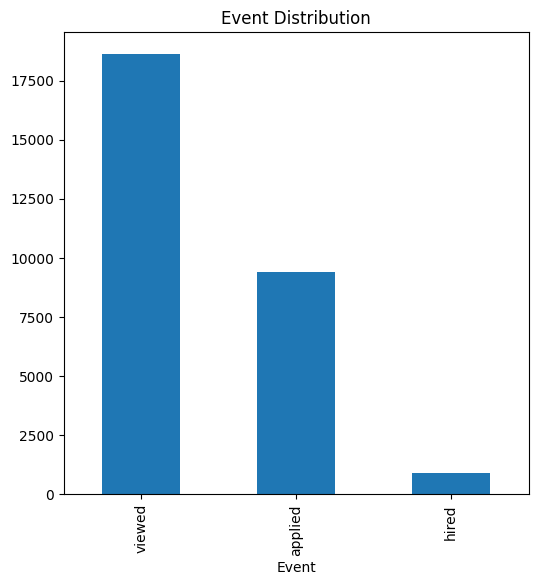

In [8]:
# Event distribution
plt.figure(figsize=(6,6))
feedbacks['Event'].value_counts().plot(kind='bar')
plt.title("Event Distribution")
plt.show()

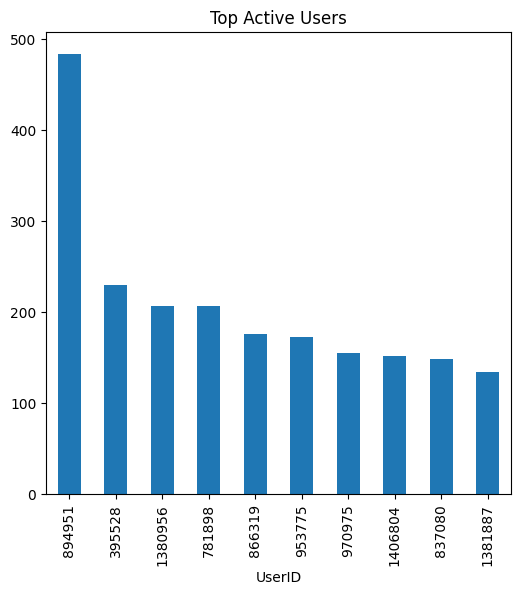

In [9]:
# Top active users
plt.figure(figsize=(6, 6))
feedbacks['UserID'].value_counts().head(10).plot(kind='bar')
plt.title("Top Active Users")
plt.show()

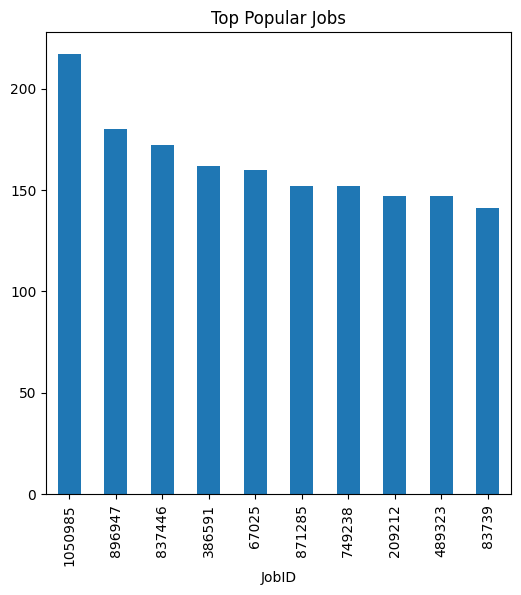

In [10]:
# Top popular jobs
plt.figure(figsize=(6,6))
feedbacks['JobID'].value_counts().head(10).plot(kind='bar')
plt.title("Top Popular Jobs")
plt.show()

In [11]:
# Monthly trend
feedbacks["Month"] = feedbacks["Date"].dt.month
monthly_trend = feedbacks.groupby("Month").size()

In [12]:
# Convert month numbers to names
monthly_trend.index = monthly_trend.index.map({
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
})

In [13]:
# Ensure correct order
monthly_trend = monthly_trend.reindex([
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])

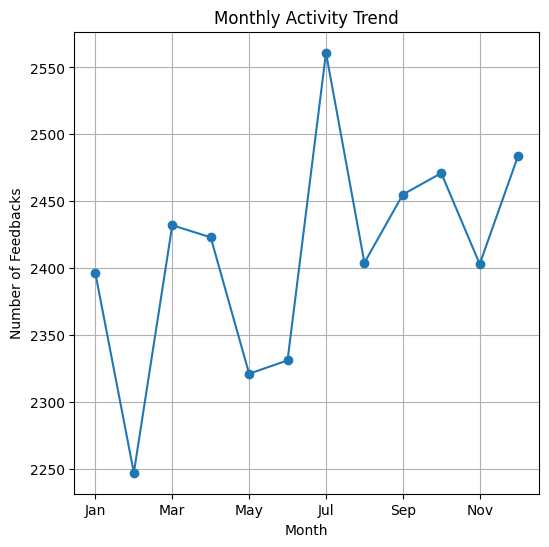

In [14]:
plt.figure(figsize=(6, 6))
monthly_trend.plot(marker="o")
plt.title("Monthly Activity Trend")
plt.xlabel("Month")
plt.ylabel("Number of Feedbacks")
plt.grid(True)
plt.show()

This section examines user interactions and activity patterns on the platform. The analysis includes the distribution of feedback events, the most active users, the most popular jobs based on user interactions, and monthly trends in platform activity over time.

## 4. Save Cleaned Dataset:

In [15]:
feedbacks.to_csv("../data/clean/feedbacks_cleaned.csv", index=False)